# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 20: FINAL PREDICTION PIPELINE FOR 10-GENRE SYSTEM
# ============================================================
# Purpose:
# This notebook implements the final 10-genre prediction
# pipeline for a new audio file using the trained structured
# model, the trained audio CNN, and the best fusion weights
# from Notebook 19.
#
# The goal is to:
# 1. Load a new audio file
# 2. Extract engineered audio features for the structured branch
# 3. Extract a Mel spectrogram for the CNN branch
# 4. Run both trained models
# 5. Fuse their probabilities using the best 10-genre weights
# 6. Return the predicted genre and confidence scores
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.stats import kurtosis, skew

In [2]:
# ============================================================
# 2. LOAD SAVED MODELS, SCALER, LABELS, AND FUSION WEIGHTS
# ============================================================

structured_model = joblib.load("../models/best_structured_model_10genre.joblib")
structured_scaler = joblib.load("../models/structured_scaler_10genre.joblib")
cnn_model = tf.keras.models.load_model("../models/improved_audio_cnn_10genre.keras")

structured_feature_columns = np.load(
    "../data/processed/structured_feature_columns_10genre.npy",
    allow_pickle=True
)

structured_classes = np.load(
    "../data/processed/structured_label_classes_10genre.npy",
    allow_pickle=True
)

cnn_classes = np.load(
    "../data/processed/cnn_label_classes_10genre.npy",
    allow_pickle=True
)

print("Loaded structured model.")
print("Loaded structured scaler.")
print("Loaded CNN model.")
print("Structured classes:", structured_classes)
print("CNN classes:", cnn_classes)

if not np.array_equal(structured_classes, cnn_classes):
    raise ValueError("Structured and CNN class orders do not match.")

class_names = structured_classes

# Best weights from Notebook 19
STRUCTURED_WEIGHT = 0.4
CNN_WEIGHT = 0.6

print("Fusion weights -> Structured:", STRUCTURED_WEIGHT, "| CNN:", CNN_WEIGHT)

Loaded structured model.
Loaded structured scaler.
Loaded CNN model.
Structured classes: ['Classical' 'Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock' 'Spoken']
CNN classes: ['Classical' 'Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock' 'Spoken']
Fusion weights -> Structured: 0.4 | CNN: 0.6


In [3]:
# ============================================================
# 3. HELPER FUNCTIONS FOR SAFE SUMMARY STATISTICS
# ============================================================

def safe_kurtosis(x):
    try:
        value = kurtosis(x, fisher=True, bias=False, nan_policy="omit")
        if np.isnan(value):
            return 0.0
        return float(value)
    except:
        return 0.0

def safe_skew(x):
    try:
        value = skew(x, bias=False, nan_policy="omit")
        if np.isnan(value):
            return 0.0
        return float(value)
    except:
        return 0.0

def compute_summary_stats(feature_matrix, feature_name):
    if feature_matrix.ndim == 1:
        feature_matrix = feature_matrix.reshape(1, -1)

    summary = {}

    for i in range(feature_matrix.shape[0]):
        values = np.asarray(feature_matrix[i], dtype=float)

        summary[f"{feature_name}_kurtosis_{i+1:02d}"] = safe_kurtosis(values)
        summary[f"{feature_name}_max_{i+1:02d}"] = float(np.nanmax(values))
        summary[f"{feature_name}_mean_{i+1:02d}"] = float(np.nanmean(values))
        summary[f"{feature_name}_median_{i+1:02d}"] = float(np.nanmedian(values))
        summary[f"{feature_name}_min_{i+1:02d}"] = float(np.nanmin(values))
        summary[f"{feature_name}_skew_{i+1:02d}"] = safe_skew(values)
        summary[f"{feature_name}_std_{i+1:02d}"] = float(np.nanstd(values))

    return summary

In [4]:
# ============================================================
# 4. EXTRACT STRUCTURED FEATURES FOR A NEW AUDIO FILE
# ============================================================

def extract_structured_features(audio_path, sr=22050, duration=30):
    y, sr = librosa.load(audio_path, sr=sr, duration=duration)
    y_harmonic = librosa.effects.harmonic(y)

    feature_dict = {}

    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_cqt = librosa.feature.chroma_cqt(y=y, sr=sr)
    chroma_cens = librosa.feature.chroma_cens(y=y, sr=sr)

    feature_dict.update(compute_summary_stats(chroma_stft, "chroma_stft"))
    feature_dict.update(compute_summary_stats(chroma_cqt, "chroma_cqt"))
    feature_dict.update(compute_summary_stats(chroma_cens, "chroma_cens"))

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    feature_dict.update(compute_summary_stats(mfcc, "mfcc"))

    rmse = librosa.feature.rms(y=y)
    feature_dict.update(compute_summary_stats(rmse, "rmse"))

    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)

    feature_dict.update(compute_summary_stats(spectral_centroid, "spectral_centroid"))
    feature_dict.update(compute_summary_stats(spectral_bandwidth, "spectral_bandwidth"))
    feature_dict.update(compute_summary_stats(spectral_contrast, "spectral_contrast"))
    feature_dict.update(compute_summary_stats(spectral_rolloff, "spectral_rolloff"))

    tonnetz = librosa.feature.tonnetz(y=y_harmonic, sr=sr)
    feature_dict.update(compute_summary_stats(tonnetz, "tonnetz"))

    zcr = librosa.feature.zero_crossing_rate(y)
    feature_dict.update(compute_summary_stats(zcr, "zcr"))

    feature_df = pd.DataFrame([feature_dict])

    feature_df = feature_df.reindex(columns=structured_feature_columns, fill_value=0.0)
    feature_df = feature_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    return feature_df

In [5]:
# ============================================================
# 5. EXTRACT MEL SPECTROGRAM FOR CNN INPUT
# ============================================================

def extract_mel_spectrogram(audio_path, sr=22050, duration=30, n_mels=128, target_width=1292):
    y, sr = librosa.load(audio_path, sr=sr, duration=duration)

    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=n_mels
    )

    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    if mel_spec_db.shape[1] < target_width:
        pad_width = target_width - mel_spec_db.shape[1]
        mel_spec_db = np.pad(
            mel_spec_db,
            ((0, 0), (0, pad_width)),
            mode="constant"
        )
    else:
        mel_spec_db = mel_spec_db[:, :target_width]

    return mel_spec_db

In [6]:
# ============================================================
# 6. DEFINE 10-GENRE PREDICTION FUNCTION
# ============================================================

def predict_genre_10genre(audio_path, structured_weight=0.4, cnn_weight=0.6, show_plot=True):
    # -------------------------------
    # Structured branch
    # -------------------------------
    structured_features = extract_structured_features(audio_path)
    structured_features_scaled = structured_scaler.transform(structured_features)
    structured_probs = structured_model.predict_proba(structured_features_scaled)[0]

    # -------------------------------
    # CNN branch
    # -------------------------------
    mel_spec = extract_mel_spectrogram(audio_path)
    cnn_input = mel_spec[np.newaxis, ..., np.newaxis].astype(np.float32)

    denom = np.max(np.abs(cnn_input))
    if denom != 0:
        cnn_input = cnn_input / denom

    cnn_probs = cnn_model.predict(cnn_input, verbose=0)[0]

    # -------------------------------
    # Hybrid fusion
    # -------------------------------
    hybrid_probs = (structured_weight * structured_probs) + (cnn_weight * cnn_probs)

    predicted_index = int(np.argmax(hybrid_probs))
    predicted_genre = class_names[predicted_index]

    top3_idx = np.argsort(hybrid_probs)[::-1][:3]
    top3_results = [(class_names[i], float(hybrid_probs[i])) for i in top3_idx]

    if show_plot:
        plt.figure(figsize=(10, 4))
        plt.bar(class_names, hybrid_probs)
        plt.xticks(rotation=45)
        plt.ylabel("Probability")
        plt.title("10-Genre Hybrid Prediction Probabilities")
        plt.tight_layout()
        plt.show()

    return {
        "predicted_genre": predicted_genre,
        "top3_predictions": top3_results,
        "structured_probs": structured_probs,
        "cnn_probs": cnn_probs,
        "hybrid_probs": hybrid_probs
    }

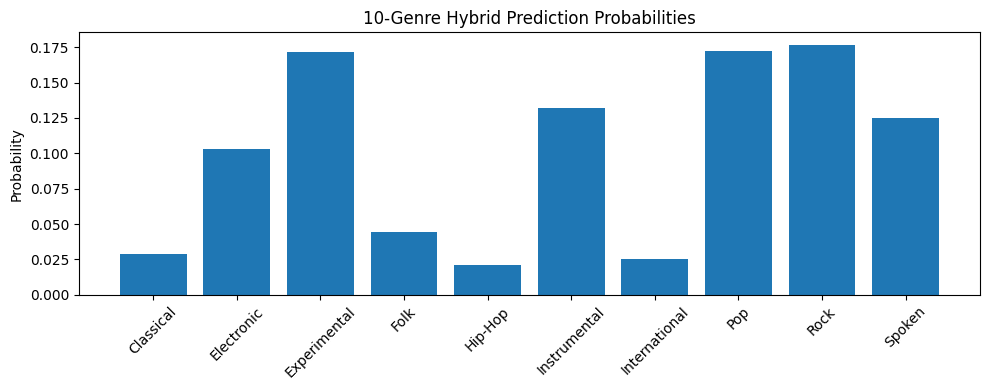

Predicted Genre: Rock

Top 3 Predictions:
Rock: 0.1767
Pop: 0.1723
Experimental: 0.1719


In [7]:
# ============================================================
# 7. TEST THE FINAL 10-GENRE PIPELINE ON A SAMPLE AUDIO FILE
# ============================================================
# Replace this path with any audio file you want to test.

sample_audio_path = "../data/raw/audio/fma_large/000/000183.mp3"

results = predict_genre_10genre(
    sample_audio_path,
    structured_weight=STRUCTURED_WEIGHT,
    cnn_weight=CNN_WEIGHT,
    show_plot=True
)

print("Predicted Genre:", results["predicted_genre"])
print("\nTop 3 Predictions:")
for genre, prob in results["top3_predictions"]:
    print(f"{genre}: {prob:.4f}")

In [8]:
# ============================================================
# 8. VIEW STRUCTURED VS CNN VS HYBRID PROBABILITIES
# ============================================================

comparison_df = pd.DataFrame({
    "Genre": class_names,
    "Structured Probability": results["structured_probs"],
    "CNN Probability": results["cnn_probs"],
    "Hybrid Probability": results["hybrid_probs"]
}).sort_values("Hybrid Probability", ascending=False)

display(comparison_df)

,Genre,Structured Probability,CNN Probability,Hybrid Probability
8,Rock,0.081187,0.240349,0.176684
7,Pop,0.373891,0.037841,0.172261
2,Experimental,0.096900,0.221877,0.171886
5,Instrumental,0.130344,0.133043,0.131963
9,Spoken,0.038077,0.182714,0.124859
1,Electronic,0.129721,0.085171,0.102991
3,Folk,0.062559,0.032643,0.044609
0,Classical,0.029883,0.027608,0.028518
6,International,0.026377,0.024181,0.025059
4,Hip-Hop,0.031062,0.014573,0.021168


In [9]:
# ============================================================
# 9. INTERPRETATION NOTES
# ============================================================

print("1. This notebook implements the final 10-genre inference pipeline.")
print("2. The structured branch uses engineered audio descriptors extracted from the new file.")
print("3. The CNN branch uses a Mel spectrogram derived directly from the new file.")
print("4. The two branches are combined using the best 10-genre fusion weights from Notebook 19.")
print("5. The final output is a predicted genre together with confidence scores.")

1. This notebook implements the final 10-genre inference pipeline.
2. The structured branch uses engineered audio descriptors extracted from the new file.
3. The CNN branch uses a Mel spectrogram derived directly from the new file.
4. The two branches are combined using the best 10-genre fusion weights from Notebook 19.
5. The final output is a predicted genre together with confidence scores.
